# 회귀 실습 — Diamonds 가격 예측

이번엔 앞서 연습한 EDA를 바탕으로 실제 **회귀 문제**를 하나 풀어보겠습니다.

사용할 데이터는 다이아몬드의 특성과 가격이 담긴 **Diamonds** 데이터셋입니다. seaborn에 내장되어 있어 별도 다운로드 없이 바로 불러올 수 있습니다.

목표는 캐럿, 컷, 색상, 투명도 등 다이아몬드의 특성으로 **가격(`price`)을 예측**하는 것입니다.

### 데이터 기본 정보

| 컬럼 | 뜻 |
|---|---|
| `carat` | 캐럿 (무게) |
| `cut` | 컷 등급 (Fair < Good < Very Good < Premium < Ideal) |
| `color` | 색상 등급 (J가 가장 낮고 D가 가장 높음) |
| `clarity` | 투명도 등급 (I1이 가장 낮고 IF가 가장 높음) |
| `depth` | 깊이 비율 (%) |
| `table` | 다이아몬드 가장 위쪽의 평평한 면의 면적 / 다이아몬드의 가장 넓은 지름 (%) |
| `price` | **가격 (정답, 단위: 달러)** |
| `x`, `y`, `z` | 가로/세로/깊이 길이 (mm) |

`cut`, `color`, `clarity`는 순서가 있는 범주형(순서형) 변수라는 점이 특징입니다. 하나씩 살펴보겠습니다.

## 1. 데이터 불러오기 & 기본 정보

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [2]:
print(df.shape)
df.info()

(53940, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


약 5만 4천 개의 관측치가 있고, `cut`/`color`/`clarity`가 문자열(object, 정확히는 category)입니다.

결측치도 확인해보겠습니다.

In [3]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

결측치는 없네요. 이번엔 예측 대상인 `price`의 분포부터 확인해보겠습니다.

## 2. 타겟(price) 분포 확인

In [4]:
df['price'].describe()

count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64

Text(0.5, 1.0, 'price')

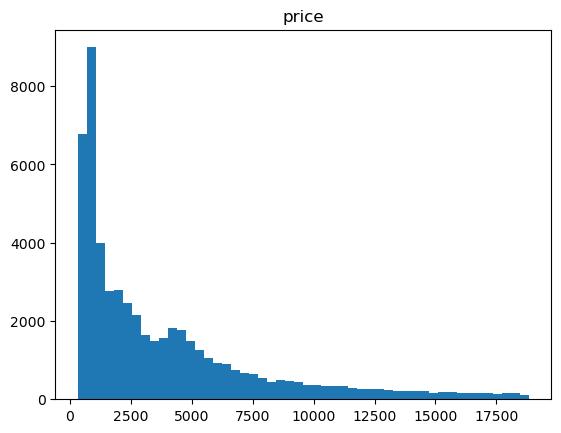

In [5]:
plt.hist(df['price'], bins=50)
plt.title("price")

`price`는 저가 다이아몬드 쪽에 크게 몰려있고 고가로 갈수록 꼬리가 길게 늘어지는 분포입니다. 이를 보면,

* 평균이 왜곡될 수 있음 : 소수 존재하는 고가의 다이아가 평균을 크게 끌어올릴 것이다.
* 이렇게 값의 분포가 한쪽으로 치우친 변수는 보통 로그 변환을 통해 이를 완화하는 방법을 많이 사용한다.

## 3. 특성 살펴보기

price에 가장 영향을 많이 미치는 특성은 어떤 걸까요?

먼저 수치형 변수들이 `price`와 어떤 관계가 있는지 산점도로 확인해보겠습니다.

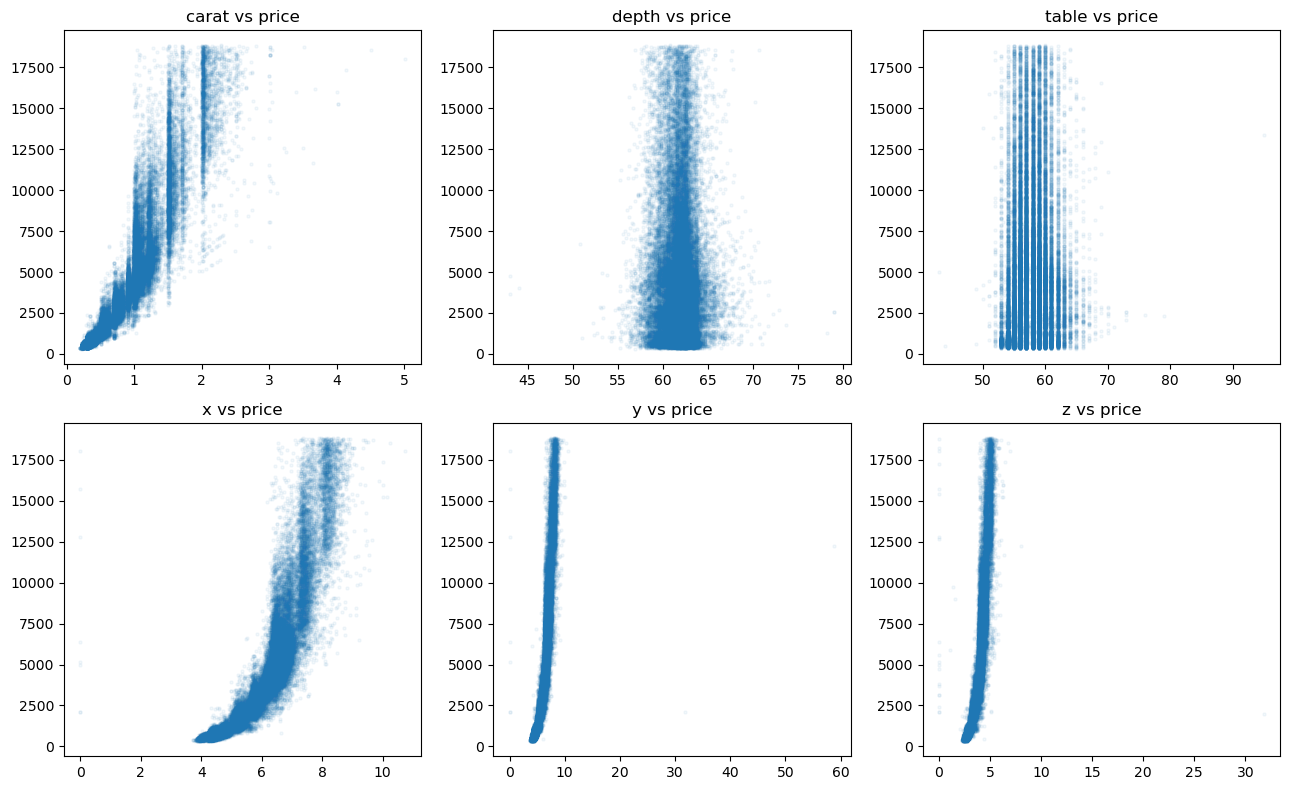

In [6]:
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.scatter(df[col], df['price'], alpha=0.05, s=5)
    ax.set_title(f"{col} vs price")
plt.tight_layout()
plt.show()

캐럿, x, y, z와 가격을 비교해 보면 서로 양의 상관관계가 있는 것을 볼 수 있습니다. 단, 직선적인 관계라기 보다는 높아질수록 더 급격하게 높아지는 관계를 갖고 있습니다.

반면 depth와 table은 둘 사이에 선형적인 관계는 보이지 않습니다.

이번엔 범주형 변수(`cut`, `color`, `clarity`)별로 가격 분포가 어떻게 다른지 박스플롯으로 확인해보겠습니다.

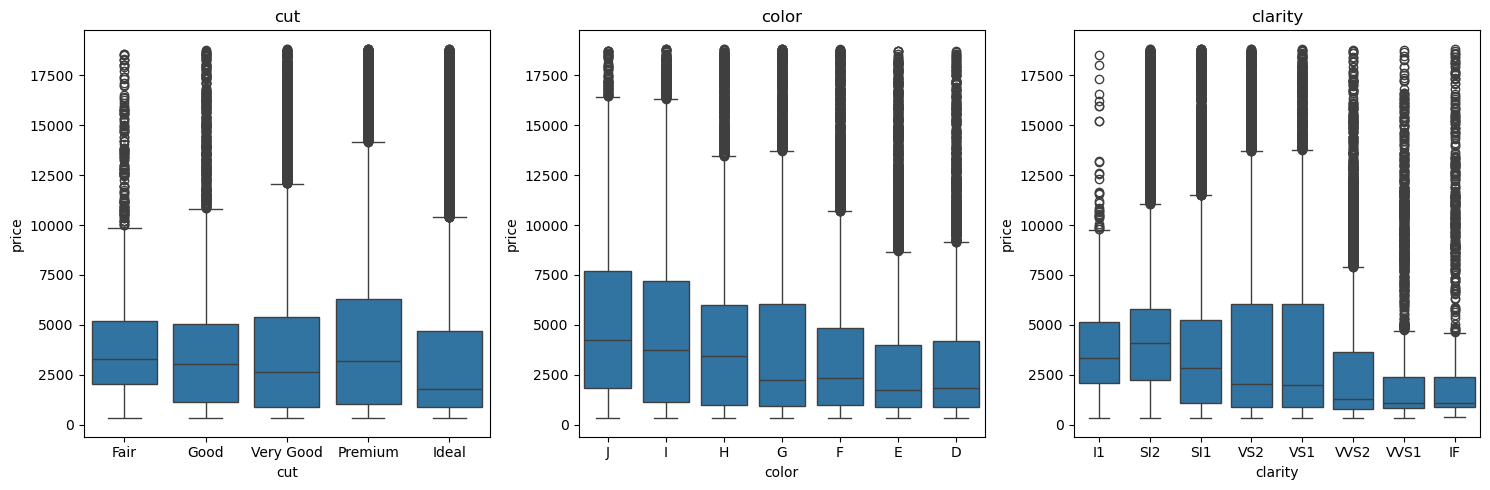

In [7]:
cat_cols = ['cut', 'color', 'clarity']
cat_orders = {
    'cut': ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    'color': ['J', 'I', 'H', 'G', 'F', 'E', 'D'],
    'clarity': ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df, x=col, y='price', order=cat_orders[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

등급이 좋을수록(오른쪽으로 갈수록) 가격이 비쌀 것 같지만, 실제론 그렇게 뚜렷하지 않죠? 오히려 `cut`이 Ideal인데도 가격 중앙값이 낮아 보입니다.

## 4. 범주형 인코딩

`cut`, `color`, `clarity`는 순서가 있는 범주형(순서형) 변수이므로, 순서 정보를 살리는 순서형 인코딩을 적용하겠습니다.

In [8]:
X = df.drop(columns=['price'])
y = df['price']

for col in cat_cols:
    order = cat_orders[col]
    mapping = {v: i for i, v in enumerate(order)}
    X[col] = X[col].map(mapping)

X.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,4,5,1,61.5,55.0,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,4.34,4.35,2.75


등급이 낮을수록 0, 높을수록 큰 숫자로 바뀐 걸 확인할 수 있습니다.

## 5. 평가지표 정하기 & train/test 분리

자, 여기서 평가 지표는 어떻게 결정하는게 좋을까요?

가격을 예측하는 문제이므로 예측값과 실제값의 차이(오차)를 그대로 보여주는 **MAE(평균 절대 오차)**를 기본 지표로 사용하겠습니다. 실제 달러 단위로 해석하기도 쉽습니다.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(43152, 9) (10788, 9)


## 6. 베이스라인 모델 학습

먼저 선형회귀로 베이스라인을 만들어보겠습니다.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)
print(f"MAE: {mae:.1f}")
print(f"RMSE: {rmse:.1f}")
print(f"R2: {r2:.1f}")

MAE: 805.3
RMSE: 1224.6
R2: 0.9


평균적으로 실제 가격과 500달러 안팎의 차이가 나네요. `price`의 평균이 약 3,900달러였던 걸 감안하면 꽤 큰 오차입니다.

RMSE가 MAE보다 훨씬 크다는 것도 눈여겨볼 부분입니다. 이는 오차가 클수록 제곱으로 커지는 RMSE 특성상, **일부 데이터에서 유독 큰 오차**가 나고 있다는 신호입니다. 어디서 이런 오차가 나는지 살펴보겠습니다.

## 7. 오차 분석

예측이 크게 틀린 구간이 있는지 살펴보겠습니다. 가장 오차가 큰 셀들을 맨 위로 정렬하여 확인해 볼까요?

In [11]:
result = X_test.copy()
result['price'] = y_test
result['pred'] = pred
result['error'] = result['pred'] - result['price']
result['abs_error'] = result['error'].abs()

result.sort_values('abs_error', ascending=False).head(10)

,carat,cut,color,clarity,depth,table,x,y,z,price,pred,error,abs_error
25998,4.01,3,1,0,61.0,61.0,10.14,10.10,6.17,15223,32427.345127,17204.345127,17204.345127
25999,4.01,3,0,0,62.5,62.0,10.02,9.94,6.24,15223,32054.799738,16831.799738,16831.799738
26444,4.00,2,1,0,63.3,58.0,10.01,9.94,6.31,15984,32198.109495,16214.109495,16214.109495
24328,3.50,4,2,0,62.8,57.0,9.65,9.59,6.03,12587,27759.085407,15172.085407,15172.085407
21862,3.01,3,4,0,62.2,56.0,9.24,9.13,5.73,9925,23429.698412,13504.698412,13504.698412
27679,3.51,3,0,3,62.5,59.0,9.66,9.63,6.03,18701,28565.175848,9864.175848,9864.175848
20297,2.50,0,3,0,65.1,59.0,8.55,8.39,5.53,8711,17509.842848,8798.842848,8798.842848
27673,1.50,2,3,3,60.7,59.0,7.31,7.38,4.46,18691,9920.447876,-8770.552124,8770.552124
17897,2.30,3,3,0,60.2,59.0,8.71,8.56,5.19,7226,15992.644824,8766.644824,8766.644824
24784,2.75,4,6,0,60.9,57.0,9.04,8.98,5.49,13156,21652.344185,8496.344185,8496.344185


가장 오차가 큰 케이스들을 보면 고가 다이아몬드에 몰려있는 걸 볼 수 있습니다. 오차는 `price`를 기준으로 계산한 값이니, 먼저 `price` 구간별로 평균 오차를 집계해서 직접 확인해보겠습니다.

In [12]:
result['price_bin'] = pd.cut(result['price'], bins=[0, 1000, 3000, 6000, 10000, 20000])
result.groupby('price_bin')[['abs_error']].mean()

C:\Users\rando\AppData\Local\Temp\ipykernel_25520\4226671074.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result.groupby('price_bin')[['abs_error']].mean()


,abs_error
price_bin,
"(0, 1000]",659.111079
"(1000, 3000]",515.804953
"(3000, 6000]",657.839691
"(6000, 10000]",980.013676
"(10000, 20000]",2237.602817


가격대가 높아질수록 평균 절대 오차도 뚜렷하게 커지는 걸 확인할 수 있습니다.

다만 price는 우리가 예측하려는 대상이라, 예측 시점에는 알 수 없는 값입니다. 오차가 어디서 크게 나는지 진단할 때는 미리 알고 있는 입력 특성(feature) 기준으로 나눠봐야 실제로 활용할 수 있는 정보가 됩니다. 그래서 price와 밀접하게 연관된 특성 중 가장 강력했던 carat 기준으로도 같은 패턴이 나타나는지 확인해보겠습니다.

In [13]:
result['carat_bin'] = pd.cut(result['carat'], bins=[0, 0.5, 1, 1.5, 2, 5])
result.groupby('carat_bin')[['abs_error']].mean()

C:\Users\rando\AppData\Local\Temp\ipykernel_25520\354613049.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result.groupby('carat_bin')[['abs_error']].mean()


,abs_error
carat_bin,
"(0.0, 0.5]",654.253769
"(0.5, 1.0]",489.626501
"(1.0, 1.5]",966.709493
"(1.5, 2.0]",1880.538001
"(2.0, 5.0]",2157.565472


역시 캐럿이 커질수록(비싼 다이아몬드일수록) 평균 절대 오차도 같이 커집니다. 저가 구간에서는 몇십 달러 수준이지만 고가 구간에서는 몇백~천 달러 단위로 틀리고 있습니다.

이럴 때 차이를 완화하기 위해 타겟을 로그 단위로 변환하는 기법을 적용하기도 합니다.

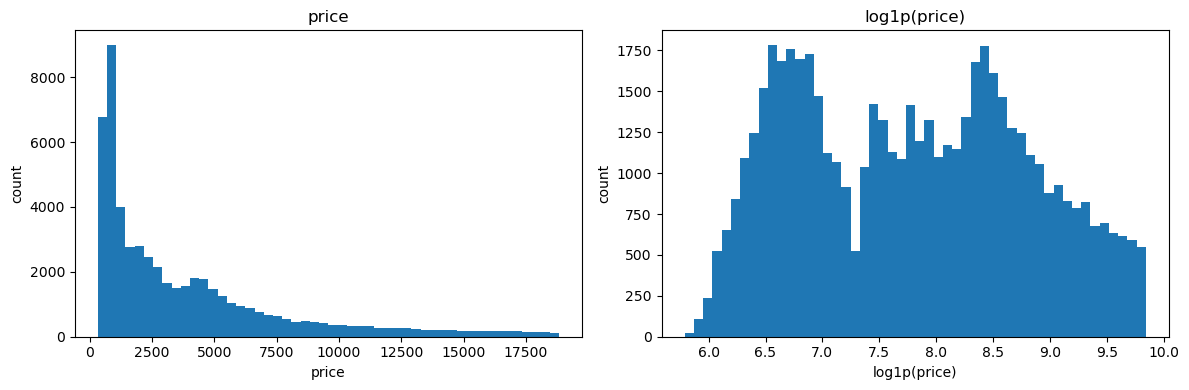

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=50)
axes[0].set_title("price")
axes[0].set_xlabel("price")
axes[0].set_ylabel("count")

axes[1].hist(np.log1p(df['price']), bins=50)
axes[1].set_title("log1p(price)")
axes[1].set_xlabel("log1p(price)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## 8. 개선 시도

`price`를 그대로 예측하는 대신, `log(price)`를 예측하도록 바꿔서 같은 방식으로 다시 학습해보겠습니다.

In [26]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

pred_log = model_log.predict(X_test)
pred_from_log = np.expm1(pred_log)   # 다시 원래 가격 단위로 복원

mae_log = mean_absolute_error(y_test, pred_from_log)
rmse_log = mean_squared_error(y_test, pred_from_log) ** 0.5
r2_log = r2_score(y_test, pred_from_log)

print(f"MAE  (기존): {mae:.1f} -> (log 변환): {mae_log:.1f}  ({(mae_log - mae) / mae * 100:+.1f}%)")
print(f"RMSE (기존): {rmse:.1f} -> (log 변환): {rmse_log:.1f}  ({(rmse_log - rmse) / rmse * 100:+.1f}%)")
print(f"R2  (기존): {r2:.2f} -> (log 변환): {r2_log:.2f}  ({(r2_log - r2) / r2 * 100:+.2f}%)")

MAE  (기존): 805.3 -> (log 변환): 536.2  (-33.4%)
RMSE (기존): 1224.6 -> (log 변환): 1221.4  (-0.3%)
R2  (기존): 0.91 -> (log 변환): 0.91  (+0.05%)


처음 베이스라인과 비교해보면 MAE와 RMSE 모두 개선된 걸 볼 수 있습니다.

한 번 의도했던 대로 고가 구간에서 오차가 줄었는지 다시 캐럿 구간 별로 나눠서 가격 비교를 해보겠습니다.

In [16]:
result['pred_log'] = pred_from_log
result['abs_error_log'] = (result['pred_log'] - result['price']).abs()

result['carat_bin'] = pd.cut(result['carat'], bins=[0, 0.5, 1, 1.5, 2, 5])
result.groupby('carat_bin')[['abs_error', 'abs_error_log']].mean()

C:\Users\rando\AppData\Local\Temp\ipykernel_25520\609645477.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result.groupby('carat_bin')[['abs_error', 'abs_error_log']].mean()


,abs_error,abs_error_log
carat_bin,,
"(0.0, 0.5]",654.253769,101.374307
"(0.5, 1.0]",489.626501,313.291875
"(1.0, 1.5]",966.709493,826.115268
"(1.5, 2.0]",1880.538001,1558.392474
"(2.0, 5.0]",2157.565472,3206.211821


고가 구간에서 오히려 오차가 증가한 것을 볼 수 있습니다! 대신 그 외의 구간들에서는 오차가 줄었습니다.

로그 변환은 모델이 "달러의 절대적인 오차" 대신에 "오차의 상대적인 비율"을 기준으로 학습하게 됩니다. 즉, 로그 변환을 하고 나서는 다이아의 가격이 높던 낮던 똑같은 비율로 오차 계산을 하게 되면서 저가 부분에선 오히려 오차가 감소했지만 고가 부분에선 오차가 증가한 것이죠.

이처럼 가설이 항상 맞을 수는 없습니다. 대신 가설을 세우고, 결과를 확인하고, 예상대로 되었는지 되지 않았는지를 분석하는 것이 더 중요하죠.

### 고가 구간 오차를 줄이기 위한 시도

로그 변환은 대부분의 구간에서 오차를 줄였지만, 가장 비싼 2캐럿 이상 구간에서는 오히려 오차가 커졌습니다. 이 구간의 오차를 실제로 줄일 수 있는 방법이 있을지 몇 가지 시도해보겠습니다.

먼저 `carat`을 있는 그대로의 숫자 대신, 구간(범주형)으로 바꿔서 넣어보면 어떨까요?

In [28]:
X_train_bin = X_train.drop(columns=['carat']).copy()
X_test_bin = X_test.drop(columns=['carat']).copy()

carat_bin_train = pd.cut(X_train['carat'], bins=[0, 0.5, 1, 1.5, 2, 5])
carat_bin_test = pd.cut(X_test['carat'], bins=[0, 0.5, 1, 1.5, 2, 5])

dummies_train = pd.get_dummies(carat_bin_train, prefix='caratbin')
dummies_test = pd.get_dummies(carat_bin_test, prefix='caratbin').reindex(columns=dummies_train.columns, fill_value=0)

X_train_bin = pd.concat([X_train_bin, dummies_train], axis=1)
X_test_bin = pd.concat([X_test_bin, dummies_test], axis=1)

model_bin = LinearRegression()
model_bin.fit(X_train_bin, y_train)
pred_bin = model_bin.predict(X_test_bin)

mae_bin = mean_absolute_error(y_test, pred_bin)
rmse_bin = mean_squared_error(y_test, pred_bin) ** 0.5
r2_bin = r2_score(y_test, pred_bin)

print(f"기존 MAE: {mae:.1f}  RMSE: {rmse:.1f}  R2: {r2:.2f}")
print(f"MAE: {mae_bin:.1f}  RMSE: {rmse_bin:.1f}  R2: {r2_bin:.2f}")

기존 MAE: 805.3  RMSE: 1224.6  R2: 0.91
MAE: 829.6  RMSE: 1227.6  R2: 0.91


이 방법을 적용했을 땐 기존보다 오히려 MAE와 RMSE가 증가한 것을 볼 수 있습니다. 하지만 저희가 궁금한 것은 고가 구간에서의 오차가 줄어들었는가 입니다. 한 번 확인해 볼까요?

In [18]:
result['pred_bin'] = pred_bin
result['abs_error_bin'] = (result['pred_bin'] - result['price']).abs()
result.groupby('carat_bin')[['abs_error', 'abs_error_bin']].mean()

C:\Users\rando\AppData\Local\Temp\ipykernel_25520\1921149682.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result.groupby('carat_bin')[['abs_error', 'abs_error_bin']].mean()


,abs_error,abs_error_bin
carat_bin,,
"(0.0, 0.5]",654.253769,677.484063
"(0.5, 1.0]",489.626501,460.931579
"(1.0, 1.5]",966.709493,1092.381552
"(1.5, 2.0]",1880.538001,1998.754520
"(2.0, 5.0]",2157.565472,1866.741065


캐럿이 낮은 구간에선 전체적으로 에러가 증가한 추세를 보이지만, 고가 구간에선 눈에 띄게 에러가 줄어든 것을 볼 수 있습니다. 만약 고가 구간에서의 에러를 낮추는 것이 더 중요하다고 한다면 MAE 자체는 기존 모델이 낮다고 하더라도 이렇게 캐럿을 구간화한 모델이 더 좋을 수 있는 것입니다.

즉, 에러만 보는 것이 아니라 그 이면에 있는 정보를 볼 수 있어야 한다는 것입니다.

## 9. 모델 비교

이제 앞서 배웠던 여러가지 모델들을 직접 학습해 보고 수치가 어떻게 변화하는지 직접 비교해 보도록 하겠습니다.

비교할 모델은 세 가지입니다.

- **선형회귀(Linear Regression)**: 앞서 베이스라인으로 사용한 모델입니다.
- **다항회귀(Polynomial Regression)**: 입력 변수들의 거듭제곱·곱셈 항을 추가해서 곡선 형태의 관계까지 학습할 수 있게 한 모델입니다.
- **ElasticNet**: 선형회귀에 규제(penalty)를 더해 과적합을 억제하는 모델입니다. 변수마다 크기 차이가 크면 규제가 고르게 적용되지 않으므로, 먼저 값의 범위를 맞춰주는 스케일링을 함께 적용합니다.

같은 `X_train`, `y_train`으로 세 모델을 학습하고, 베이스라인과 MAE·RMSE를 비교해보겠습니다.

In [19]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

elastic_model = make_pipeline(StandardScaler(), ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42))
elastic_model.fit(X_train, y_train)
pred_elastic = elastic_model.predict(X_test)

r2 = r2_score(y_test, pred)

compare = pd.DataFrame({
    'MAE': [
        mae,
        mean_absolute_error(y_test, pred_poly),
        mean_absolute_error(y_test, pred_elastic),
    ],
    'RMSE': [
        rmse,
        mean_squared_error(y_test, pred_poly) ** 0.5,
        mean_squared_error(y_test, pred_elastic) ** 0.5,
    ],
    'R2': [
        r2,
        r2_score(y_test, pred_poly),
        r2_score(y_test, pred_elastic),
    ],
}, index=['Linear Regression', 'Polynomial Regression (degree=2)', 'ElasticNet'])
compare

,MAE,RMSE,R2
Linear Regression,805.274366,1224.596542,0.905664
Polynomial Regression (degree=2),462.511466,778.425752,0.961883
ElasticNet,1063.358343,1592.517709,0.840464


세 모델의 결과가 뚜렷하게 갈립니다.

- **다항회귀**는 MAE 805.3 → 462.5, RMSE 1224.6 → 778.4, R2 0.906 → 0.962로 세 모델 중 가장 좋습니다. 캐럿 등 변수가 가격에 곡선 형태로 영향을 준다는 걸 앞서 산점도에서도 확인했는데, 이 곡선 관계를 모델이 직접 학습할 수 있게 되면서 오차가 크게 줄고 설명력(R2)도 높아졌습니다.
- **ElasticNet**은 오히려 MAE 1063.4, RMSE 1592.5, R2 0.840으로 베이스라인보다 나빠졌습니다. 규제가 계수 크기를 줄이는 방향으로 작동하다 보니, 지금처럼 규제 강도(`alpha`)를 임의로 정한 상태에서는 모델이 필요한 만큼 변수를 반영하지 못해 오히려 과소적합된 것입니다.

R2는 모델이 `price`의 분산을 얼마나 설명하는지를 0~1 사이 값으로 보여줍니다. 1에 가까울수록 설명력이 높다는 뜻으로, MAE·RMSE(달러 단위 오차)와 달리 스케일에 관계없이 모델 간 설명력을 비교하기 좋은 지표입니다.

즉, 모델을 복잡하게 만드는 것(다항회귀)과 규제를 거는 것(ElasticNet)은 반대 방향의 시도입니다. 데이터와 문제에 따라 어느 쪽이 맞는지가 다르며, ElasticNet처럼 규제가 있는 모델은 `alpha`, `l1_ratio` 같은 하이퍼파라미터를 데이터에 맞게 조정해야 제 성능이 나옵니다.